# Homework 1

## FINM 35700 - Spring 2026

### UChicago Financial Mathematics

* Alex Popovici
* alex.popovici@uchicago.edu

This homework relies on:

- the government and corporate bonds symbology file `bond_symbology`, 
- the "on-the-run" treasuries data file `govt_on_the_run` and
- the market data file `market_prices_eod`.


You can find more details on US treasury instruments in the FINM 37400 Fixed Income course.



In [70]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import re
pd.reset_option('display.max_columns')


------------------------------------------------------------------------------------------
# Problem 1: Explore symbology for US treasury bonds

## a. Load and explore US government bond symbology

Load the `bond_symbology` Excel file into a dataframe. It contains symbology for both government and corporate bonds as of 2026-03-23.

Select US Treasury bonds only (class = 'Govt', ticker = 'T'). For each government bond issue, calculate its initial `term` in years (based on issue date and maturity date), as well as the current `TTM` (time-to-maturity) and extend the dataframe. Assume a year has 365.25 days.


In [2]:
bond_symbology_df = pd.read_excel('data/bond_symbology.xlsx')
bond_symbology_df.head()

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status
0,AAPL,Corp,BBG004HST0K7,US037833AL42,US912810UT33,AAPL 3.85 05/04/43,APPLE INC,GLOBAL,3.850,FIXED,...,2013-05-03,2013-11-04,2013-05-03,2043-05-04,AT MATURITY,Sr Unsecured,3000.0,US,USD,ACTV
1,AAPL,Corp,BBG006F8VWJ7,US037833AT77,US912810UT33,AAPL 4.45 05/06/44,APPLE INC,GLOBAL,4.450,FIXED,...,2014-05-06,2014-11-06,2014-05-06,2044-05-06,AT MATURITY,Sr Unsecured,1000.0,US,USD,ACTV
2,AAPL,Corp,BBG0081TNL50,US037833BA77,US912810UT33,AAPL 3.45 02/09/45,APPLE INC,GLOBAL,3.450,FIXED,...,2015-02-09,2015-08-09,2015-02-09,2045-02-09,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV
3,AAPL,Corp,BBG008N1BQC1,US037833BH21,US912810UT33,AAPL 4 3/8 05/13/45,APPLE INC,GLOBAL,4.375,FIXED,...,2015-05-13,2015-11-13,2015-05-13,2045-05-13,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV
4,AAPL,Corp,BBG00C7QBCQ1,US037833BW97,US91282CPZ85,AAPL 4 1/2 02/23/36,APPLE INC,GLOBAL,4.500,FIXED,...,2016-02-23,2016-08-23,2016-02-23,2036-02-23,CALLABLE,Sr Unsecured,1250.0,US,USD,ACTV


In [3]:
bond_symbology_df = bond_symbology_df[(bond_symbology_df['class'] == 'Govt') & (bond_symbology_df['ticker'] == 'T')]
bond_symbology_df.head()

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status
893,T,Govt,BBG000DKHP42,US912810EG95,US9127963M90,T 8 3/4 08/15/20,US TREASURY N/B,US GOVERNMENT,8.750,FIXED,...,1990-08-15,1991-02-15,1990-08-15,2020-08-15,NORMAL,Unsecured,17059.0,US,USD,INAC
894,T,Govt,BBG000DJN4B7,US912810EH78,NaN,T 7 7/8 02/15/21,US TREASURY N/B,US GOVERNMENT,7.875,FIXED,...,1991-02-15,1991-08-15,1991-02-15,2021-02-15,NORMAL,Unsecured,10076.0,US,USD,INAC
895,T,Govt,BBG000DHBM88,US912810EJ35,NaN,T 8 1/8 05/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-05-15,1991-11-15,1991-05-15,2021-05-15,NORMAL,Unsecured,10067.0,US,USD,INAC
896,T,Govt,BBG000DKP182,US912810EK08,NaN,T 8 1/8 08/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-08-15,1992-02-15,1991-08-15,2021-08-15,NORMAL,Unsecured,9506.0,US,USD,INAC
897,T,Govt,BBG000DFRYP0,US912810EL80,NaN,T 8 11/15/21,US TREASURY N/B,US GOVERNMENT,8.000,FIXED,...,1991-11-15,1992-05-15,1991-11-15,2021-11-15,NORMAL,Unsecured,30632.0,US,USD,INAC


In [4]:
bond_symbology_df['term'] = (bond_symbology_df['maturity'] - bond_symbology_df['start_date']).dt.days/ 365.25
bond_symbology_df['TTM'] = np.maximum((bond_symbology_df['maturity'] - pd.to_datetime('2026-03-23')).dt.days/ 365.25, 0)
bond_symbology_df.head()


,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status,term,TTM
893,T,Govt,BBG000DKHP42,US912810EG95,US9127963M90,T 8 3/4 08/15/20,US TREASURY N/B,US GOVERNMENT,8.750,FIXED,...,1990-08-15,2020-08-15,NORMAL,Unsecured,17059.0,US,USD,INAC,30.001369,0.0
894,T,Govt,BBG000DJN4B7,US912810EH78,NaN,T 7 7/8 02/15/21,US TREASURY N/B,US GOVERNMENT,7.875,FIXED,...,1991-02-15,2021-02-15,NORMAL,Unsecured,10076.0,US,USD,INAC,30.001369,0.0
895,T,Govt,BBG000DHBM88,US912810EJ35,NaN,T 8 1/8 05/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-05-15,2021-05-15,NORMAL,Unsecured,10067.0,US,USD,INAC,30.001369,0.0
896,T,Govt,BBG000DKP182,US912810EK08,NaN,T 8 1/8 08/15/21,US TREASURY N/B,US GOVERNMENT,8.125,FIXED,...,1991-08-15,2021-08-15,NORMAL,Unsecured,9506.0,US,USD,INAC,30.001369,0.0
897,T,Govt,BBG000DFRYP0,US912810EL80,NaN,T 8 11/15/21,US TREASURY N/B,US GOVERNMENT,8.000,FIXED,...,1991-11-15,2021-11-15,NORMAL,Unsecured,30632.0,US,USD,INAC,30.001369,0.0


## b. Historical time series of US treasury coupons 

Plot the time series of coupons for for US treasury notes/bonds issued since 2019 (indexed by issue date). 
What can you say about the overall level of issued coupons since 2024?


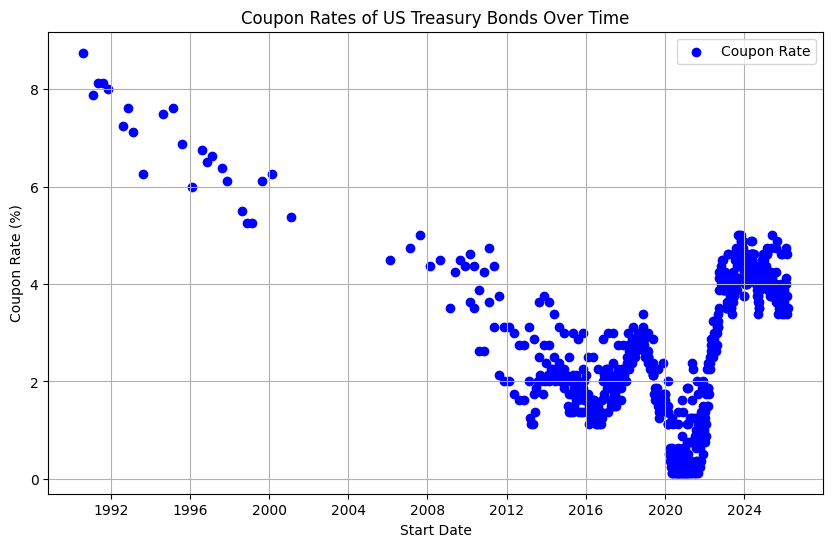

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(bond_symbology_df['start_date'], bond_symbology_df['coupon'], color='blue', label='Coupon Rate')
plt.xlabel('Start Date')
plt.ylabel('Coupon Rate (%)')
plt.title('Coupon Rates of US Treasury Bonds Over Time')
plt.legend()
plt.grid(True)
plt.show()

#### - The overall level of issued coupons released since 2024 has decreased over time and rose after 2020

## c. Load the on-the-run US treasuries

Load the `govt_on_the_run` Excel file into a dataframe. Select the current on-the-run 2Y, 3Y, 5Y, 7Y, 10Y, 20Y and 30Y issues (off-the-run issues have the B & C suffix). Create a separate symbology dataframe for on-the-run treasuries only, to be used later on for the on-the-run government yield curve bootstrapping.

In [6]:
govt_bonds_df = pd.read_excel('data/govt_on_the_run.xlsx')
pattern = r'GT[0-9]+ Govt'
mask = govt_bonds_df['ticker'].str.contains(pattern, regex=True)
govt_bonds_df = govt_bonds_df[mask]
govt_bonds_df.head()

,ticker,date,figi,isin
0,GT10 Govt,2026-03-23,BBG01ZZ4GDR9,US91282CPZ85
3,GT2 Govt,2026-03-23,BBG020BMV715,US91282CQB09
4,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33
9,GT3 Govt,2026-03-23,BBG020PVMGR2,US91282CQE48
10,GT30 Govt,2026-03-23,BBG01ZZ4GDS8,US912810UR76


In [7]:
on_the_run_govt_bonds_df = bond_symbology_df[bond_symbology_df['isin'].isin(govt_bonds_df['isin']) & (bond_symbology_df['figi'].isin(govt_bonds_df['figi']))]
on_the_run_govt_bonds_df

,ticker,class,figi,isin,und_bench_isin,security,name,type,coupon,cpn_type,...,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status,term,TTM
1013,T,Govt,BBG01ZZ4GDS8,US912810UR76,US912810UR76,T 4 3/4 02/15/56,US TREASURY N/B,US GOVERNMENT,4.750,FIXED,...,2026-02-15,2056-02-15,NORMAL,Unsecured,32084.0,US,USD,ACTV,29.993155,29.900068
1014,T,Govt,BBG02037XBW2,US912810UT33,US912810UQ93,T 4 5/8 02/15/46,US TREASURY N/B,US GOVERNMENT,4.625,FIXED,...,2026-02-15,2046-02-15,NORMAL,Unsecured,17917.0,US,USD,ACTV,19.958932,19.901437
1553,T,Govt,BBG01ZZ4GDR9,US91282CPZ85,US91282CPZ85,T 4 1/8 02/15/36,US TREASURY N/B,US GOVERNMENT,4.125,FIXED,...,2026-02-15,2036-02-15,NORMAL,Unsecured,53901.0,US,USD,ACTV,9.993155,9.900068
1555,T,Govt,BBG020BMV715,US91282CQB09,US91282CQB09,T 3 3/8 02/29/28,US TREASURY N/B,US GOVERNMENT,3.375,FIXED,...,2026-02-28,2028-02-29,NORMAL,Unsecured,77266.0,US,USD,ACTV,1.995893,1.938398
1556,T,Govt,BBG020BMV6Z0,US91282CQC81,US91282CQC81,T 3 3/4 02/28/33,US TREASURY N/B,US GOVERNMENT,3.750,FIXED,...,2026-02-28,2033-02-28,NORMAL,Unsecured,49271.0,US,USD,ACTV,6.995209,6.937714
1557,T,Govt,BBG020BMV760,US91282CQD64,US91282CQD64,T 3 1/2 02/28/31,US TREASURY N/B,US GOVERNMENT,3.500,FIXED,...,2026-02-28,2031-02-28,NORMAL,Unsecured,78386.0,US,USD,ACTV,4.993840,4.936345
1558,T,Govt,BBG020PVMGR2,US91282CQE48,US91282CQE48,T 3 1/2 03/15/29,US TREASURY N/B,US GOVERNMENT,3.500,FIXED,...,2026-03-15,2029-03-15,NORMAL,Unsecured,58015.0,US,USD,ACTV,2.997947,2.978782


## d. Compute the total amount of US Treasuries issued / matured every year since 2019

Column `amt_out` contains the issue amount outstanding, expressed in $MM.

Compute the total amount of US Treasuries issued every year since 2019.
Compute the total amount of US Treasuries matured every year since 2019.

Plot the results.

In [8]:
issued = bond_symbology_df.copy()
issued['issue_year'] = issued['start_date'].dt.year
issued['maturity'] = issued['maturity'].dt.year
issued.reset_index(inplace=True, drop=True)
issued.head()
total_issued = issued.groupby('issue_year')['amt_out'].sum()
total_matured = issued.groupby('maturity')['amt_out'].sum()
post_2019_issue = total_issued[total_issued.index >= 2019]
post_2019_matured = total_matured[total_matured.index >= 2019]
post_2019_issue

issue_year
2019    2322466.0
2020    3558513.0
2021    4601404.0
2022    3251806.0
2023    3028042.0
2024    4012135.0
2025    3817659.0
2026     638191.0
Name: amt_out, dtype: float64

In [9]:
post_2019_matured

maturity
2020     609714.0
2021    2068029.0
2022    2249135.0
2023    2631092.0
2024    2629231.0
2025    2546043.0
2026    2922688.0
2027    3148505.0
2028    2622922.0
2029    1968116.0
2030    1770500.0
2031    1282647.0
2032    1078999.0
2033     556431.0
2034     476991.0
2035     383640.0
2036      80298.0
2037      38002.0
2038      48025.0
2039     150683.0
2040     396120.0
2041     497550.0
2042     364121.0
2043     338740.0
2044     314990.0
2045     279799.0
2046     183906.0
2047     169267.0
2048     198450.0
2049     236479.0
2050     308693.0
2051     366237.0
2052     297702.0
2053     266595.0
2054     275118.0
2055     223083.0
2056      32084.0
Name: amt_out, dtype: float64

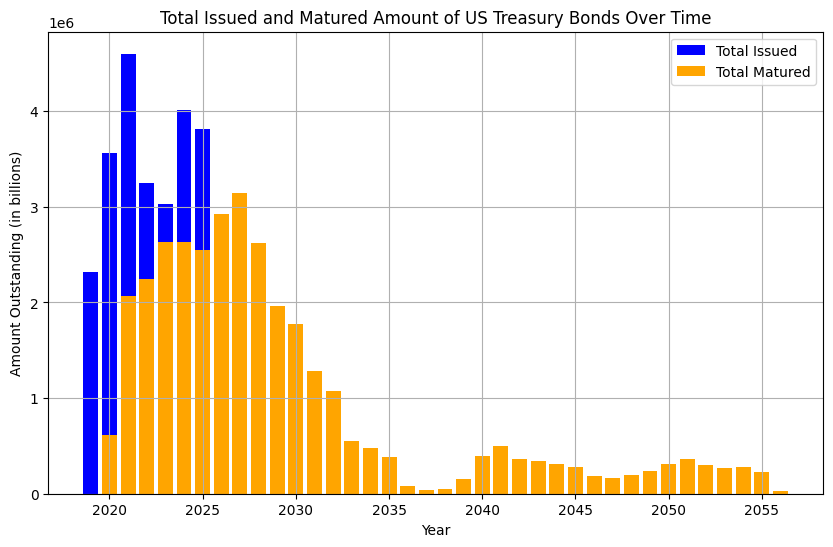

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(post_2019_issue.index, post_2019_issue.values, color='blue', label='Total Issued')
plt.bar(post_2019_matured.index, post_2019_matured.values, color='orange', label='Total Matured')
plt.xlabel('Year')
plt.ylabel('Amount Outstanding (in billions)')
plt.title('Total Issued and Matured Amount of US Treasury Bonds Over Time')
plt.legend()
plt.grid(True)
plt.show()

------------------------------------------------------------------------------------------
# Problem 2: Explore symbology for corporate bonds

## a. Load and explore US corporate bonds symbology data

Starting from the `bond_symbology` dataframe, create a corporate bond dataframe containing
* corporate bond only  (class = "Corp"),
* senior unsecured (rank = "Sr Unsecured"),
* fixed coupon (cpn_type="FIXED")
* maturity date <= 2055-12-31

bonds only, with following columns:



| ticker | isin | figi | security | name | coupon | start_date | maturity | amt_out | term | TTM |
|----------|-------|-------|-------------|-----|----------|---------|---------|---------|---------|---------|

where 
* `term` refers to the initial term/time-to-maturity in years
* `TTM` refers to the current time-to-maturity in years

Display the dataframe.

In [28]:
bond_symbology_df = pd.read_excel('data/bond_symbology.xlsx')
bond_symbology_df = bond_symbology_df[(bond_symbology_df['class'] == 'Corp') & (bond_symbology_df['rank'] == 'Sr Unsecured') & (bond_symbology_df['cpn_type'] == 'FIXED') & (bond_symbology_df['maturity'] <= pd.to_datetime('2055-12-31'))]
bond_symbology_df.head()
result_df = bond_symbology_df[['ticker', 'isin', 'figi', 'security', 'name', 'coupon', 'start_date', 'maturity', 'amt_out']]
result_df['term'] = (result_df['maturity'] - result_df['start_date']).dt.days/ 365.25
result_df['TTM'] = np.maximum((result_df['maturity'] - pd.to_datetime('2026-03-23')).dt.days/ 365.25, 0)
result_df.head()

,ticker,isin,figi,security,name,coupon,start_date,maturity,amt_out,term,TTM
0,AAPL,US037833AL42,BBG004HST0K7,AAPL 3.85 05/04/43,APPLE INC,3.850,2013-05-03,2043-05-04,3000.0,30.001369,17.114305
1,AAPL,US037833AT77,BBG006F8VWJ7,AAPL 4.45 05/06/44,APPLE INC,4.450,2014-05-06,2044-05-06,1000.0,30.001369,18.121834
2,AAPL,US037833BA77,BBG0081TNL50,AAPL 3.45 02/09/45,APPLE INC,3.450,2015-02-09,2045-02-09,2000.0,30.001369,18.885695
3,AAPL,US037833BH21,BBG008N1BQC1,AAPL 4 3/8 05/13/45,APPLE INC,4.375,2015-05-13,2045-05-13,2000.0,30.001369,19.140315
4,AAPL,US037833BW97,BBG00C7QBCQ1,AAPL 4 1/2 02/23/36,APPLE INC,4.500,2016-02-23,2036-02-23,1250.0,20.000000,9.921971


## b. Explore aggregated issue amount outstanding by issuer

Compute the total issue (face) amount outstanding for each issuer and display the results.

In [12]:
total_issue_amount = result_df.groupby('name')['amt_out'].sum()
total_issue_amount.sort_values(ascending=False).head(30)

name
ORACLE CORP                 102490.435000
VERIZON COMMUNICATIONS       88745.606188
APPLE INC                    65100.000000
META PLATFORMS INC           48614.249000
GENERAL MOTORS FINL CO       37703.712000
FORD MOTOR CREDIT CO LLC     35561.931000
MICROSOFT CORP               31642.036000
IBM CORP                     30334.172000
WALT DISNEY COMPANY/THE      26625.751000
JPMORGAN CHASE & CO          11296.695450
MORGAN STANLEY               10735.446000
NVIDIA CORP                   7000.000000
Name: amt_out, dtype: float64

## c. Display the bond details for APPLE INC (ticker AAPL)

Create a separate dataframe for Apple issuer only (ticker = 'AAPL') and display it.

Compute following aggregated metrics for AAPL:
* average coupon
* average term and
* average TTM.

In [13]:
apple_df = result_df[result_df['name'] == 'APPLE INC']
coupon = apple_df['coupon'].mean()
term = apple_df['term'].mean()
avg_TTM = apple_df['TTM'].mean()

print(f"Average Coupon Rate for Apple Inc: {coupon:.2f}%")
print(f"Average Term for Apple Inc: {term:.2f} years")
print(f"Average Time to Maturity for Apple Inc: {avg_TTM:.2f} years")

Average Coupon Rate for Apple Inc: 3.29%
Average Term for Apple Inc: 17.90 years
Average Time to Maturity for Apple Inc: 11.69 years


## d. Explore term structure of issue amounts outstanding for Apple.

Plot the issue amount outstanding by TTM for Apple.

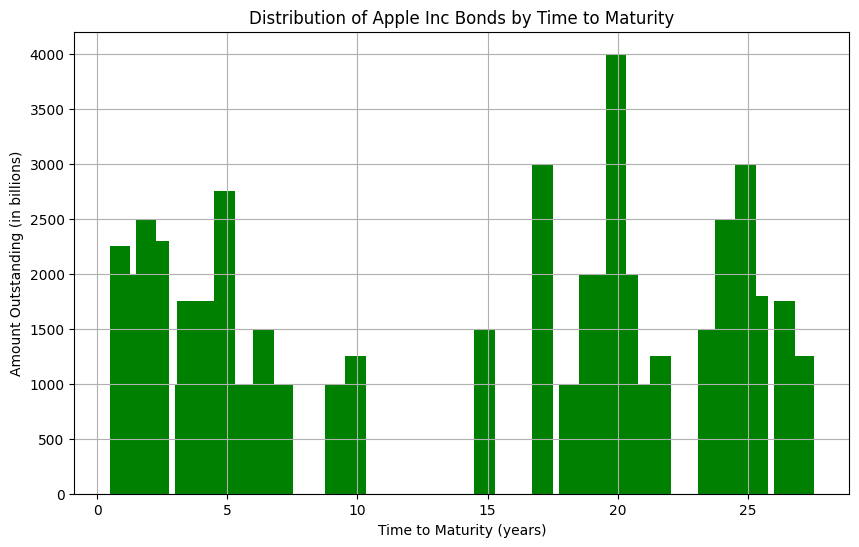

In [14]:
issue_by_TTM = apple_df.groupby('TTM')['amt_out'].sum()
plt.figure(figsize=(10, 6))
plt.bar(issue_by_TTM.index, issue_by_TTM.values, color='green')
plt.xlabel('Time to Maturity (years)')
plt.ylabel('Amount Outstanding (in billions)')
plt.title('Distribution of Apple Inc Bonds by Time to Maturity')
plt.grid(True)
plt.show()

------------------------------------------------------------------------------------------
# Problem 3: Explore EOD market prices and yields

## a. Load and explore treasury market prices and yields

Load the `bond_market_prices_eod` Excel file into a dataframe. It provides market data for US treasuries and corporate bonds as of 2026-03-23.

Merge the treasuries symbology dataframe with the market data and add the following columns:


| date | bidPrice | askPrice | midPrice | bidYield | askYield | midYield | term | TTM |
|----------|-------|-------------|-----|----------|---------|---------|---------|---------|

Plot a graph/scatter plot of treasury mid yields by TTM.


In [15]:
bond_market_prices_df = pd.read_excel('data/bond_market_prices_eod.xlsx')
bond_market_prices_df

,date,class,ticker,isin,figi,bidPrice,askPrice,bidYield,askYield
0,2026-03-23,Corp,AAPL,US037833AL42,BBG004HST0K7,82.414444,82.414444,5.442,5.442
1,2026-03-23,Corp,AAPL,US037833AT77,BBG006F8VWJ7,89.116091,89.116091,5.399,5.399
2,2026-03-23,Corp,AAPL,US037833BA77,BBG0081TNL50,75.855577,75.855577,5.526,5.526
3,2026-03-23,Corp,AAPL,US037833BH21,BBG008N1BQC1,86.818216,86.818216,5.497,5.497
4,2026-03-23,Corp,AAPL,US037833BW97,BBG00C7QBCQ1,99.575093,99.575093,4.553,4.553
...,...,...,...,...,...,...,...,...,...
517,2026-03-23,Corp,VZ,US92343VHH06,BBG01YGN1120,97.010922,97.010922,6.010,6.010
518,2026-03-23,Corp,VZ,US92343VHJ61,BBG01YGN10R5,97.106959,97.106959,6.086,6.086
519,2026-03-23,Corp,VZ,US92343VHK35,BBG01YGN12L7,96.849068,96.849068,6.214,6.214
520,2026-03-23,Corp,VZ,US92344GAM87,BBG00003TCX8,112.648714,112.648714,4.708,4.708


In [16]:
bond_symbology_df = pd.read_excel('data/bond_symbology.xlsx')
bond_symbology_df['term'] = (bond_symbology_df['maturity'] - bond_symbology_df['start_date']).dt.days/ 365.25
bond_symbology_df['TTM'] = np.maximum((bond_symbology_df['maturity'] - pd.to_datetime('2026-03-23')).dt.days/ 365.25, 0)
merged_corporate = bond_symbology_df.merge(bond_market_prices_df, on=['figi', 'isin'], how = 'inner')[['date', 'bidPrice', 'askPrice', 'bidYield', 'askYield', 'term', 'TTM']]
merged_corporate['midPrice'] = (merged_corporate['bidPrice'] + merged_corporate['askPrice']) / 2
merged_corporate['midYield'] = (merged_corporate['bidYield'] + merged_corporate['askYield']) / 2
merged_corporate.head()

,date,bidPrice,askPrice,bidYield,askYield,term,TTM,midPrice,midYield
0,2026-03-23,82.414444,82.414444,5.442,5.442,30.001369,17.114305,82.414444,5.442
1,2026-03-23,89.116091,89.116091,5.399,5.399,30.001369,18.121834,89.116091,5.399
2,2026-03-23,75.855577,75.855577,5.526,5.526,30.001369,18.885695,75.855577,5.526
3,2026-03-23,86.818216,86.818216,5.497,5.497,30.001369,19.140315,86.818216,5.497
4,2026-03-23,99.575093,99.575093,4.553,4.553,20.000000,9.921971,99.575093,4.553


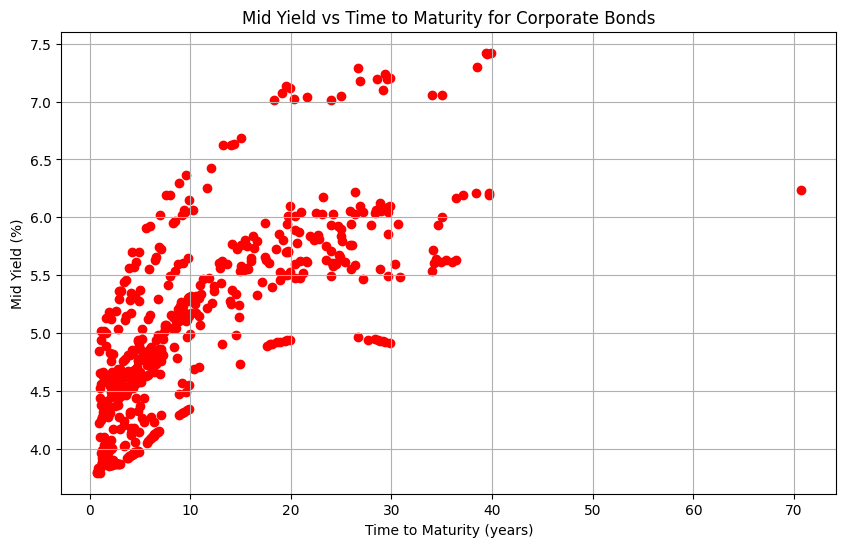

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_corporate['TTM'], merged_corporate['midYield'], color='red')
plt.xlabel('Time to Maturity (years)')
plt.ylabel('Mid Yield (%)')
plt.title('Mid Yield vs Time to Maturity for Corporate Bonds')
plt.grid(True)
plt.show()

## b. Explore on-the-run treasuries only
Create a separate joint dataframe for on-the-run treasuries only.

Plot a graph/scatter plot of on-the-run treasury mid yields by TTM.

In [18]:
on_the_run_govt_bonds_df['term'] = (on_the_run_govt_bonds_df['maturity'] - on_the_run_govt_bonds_df['start_date']).dt.days/ 365.25
on_the_run_govt_bonds_df['TTM'] = np.maximum((on_the_run_govt_bonds_df['maturity'] - pd.to_datetime('2026-03-23')).dt.days/ 365.25, 0)
on_the_run_treasury = on_the_run_govt_bonds_df.merge(bond_market_prices_df, on=['figi', 'isin'], how = 'inner')[['date', 'bidPrice', 'askPrice', 'bidYield', 'askYield', 'term', 'TTM']]
on_the_run_treasury['midPrice'] = (on_the_run_treasury['bidPrice'] + on_the_run_treasury['askPrice']) / 2
on_the_run_treasury['midYield'] = (on_the_run_treasury['bidYield'] + on_the_run_treasury['askYield']) / 2
on_the_run_treasury.head()

,date,bidPrice,askPrice,bidYield,askYield,term,TTM,midPrice,midYield
0,2026-03-23,97.4531,97.5000,4.918,4.913,29.993155,29.900068,97.47655,4.9155
1,2026-03-23,96.0781,96.1093,4.941,4.936,19.958932,19.901437,96.09370,4.9385
2,2026-03-23,98.3125,98.3437,4.348,4.342,9.993155,9.900068,98.32810,4.3450
3,2026-03-23,99.1562,99.1601,3.856,3.852,1.995893,1.938398,99.15815,3.8540
4,2026-03-23,97.6562,97.6718,4.158,4.153,6.995209,6.937714,97.66400,4.1555


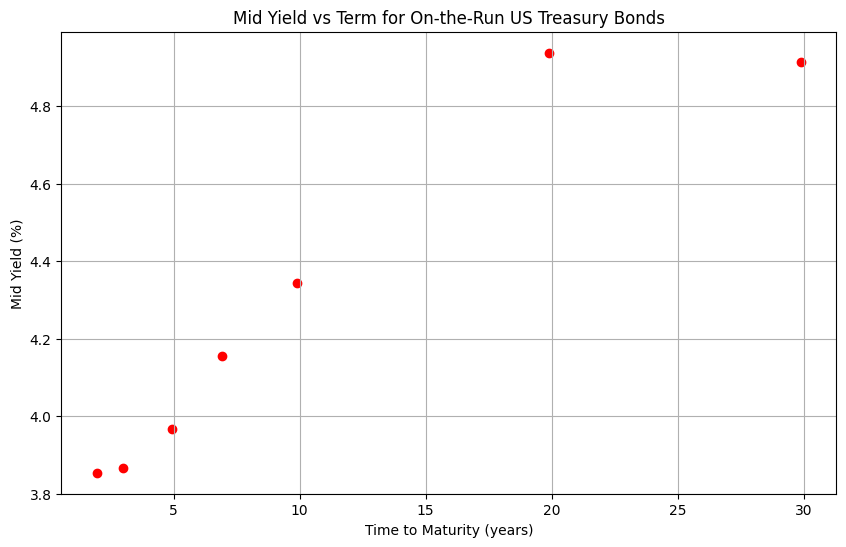

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(on_the_run_treasury['TTM'], on_the_run_treasury['midYield'], color='red')
plt.xlabel('Time to Maturity (years)')
plt.ylabel('Mid Yield (%)')
plt.title('Mid Yield vs Term for On-the-Run US Treasury Bonds')
plt.grid(True)
plt.show()

## c. Load and explore corporate bond market prices and yields

Merge the filtered corporate bonds symbology dataframe with the market data and add the following columns:

| date | bidPrice | askPrice | midPrice | bidYield | askYield | midYield | term | TTM |
|----------|-------|-------------|-----|----------|---------|---------|---------|---------|

List the unique tickers/issuers available in the dataframe.


In [29]:
result_df.columns

Index(['ticker', 'isin', 'figi', 'security', 'name', 'coupon', 'start_date',
       'maturity', 'amt_out', 'term', 'TTM'],
      dtype='str')

In [33]:
corporate_bond_merged = result_df.merge(bond_market_prices_df, on=['figi', 'isin'], how = 'inner')[['ticker_x','date','bidPrice', 'askPrice', 'bidYield', 'askYield', 'term', 'TTM']]
corporate_bond_merged['midPrice'] = (corporate_bond_merged['bidPrice'] + corporate_bond_merged['askPrice']) / 2
corporate_bond_merged['midYield'] = (corporate_bond_merged['bidYield'] + corporate_bond_merged['askYield']) / 2
corporate_bond_merged.head()

,ticker_x,date,bidPrice,askPrice,bidYield,askYield,term,TTM,midPrice,midYield
0,AAPL,2026-03-23,82.414444,82.414444,5.442,5.442,30.001369,17.114305,82.414444,5.442
1,AAPL,2026-03-23,89.116091,89.116091,5.399,5.399,30.001369,18.121834,89.116091,5.399
2,AAPL,2026-03-23,75.855577,75.855577,5.526,5.526,30.001369,18.885695,75.855577,5.526
3,AAPL,2026-03-23,86.818216,86.818216,5.497,5.497,30.001369,19.140315,86.818216,5.497
4,AAPL,2026-03-23,99.575093,99.575093,4.553,4.553,20.000000,9.921971,99.575093,4.553


In [34]:
unique_ticker = result_df['ticker'].unique()
print("Unique Tickers in the Result DataFrame:")
print(unique_ticker)

Unique Tickers in the Result DataFrame:
<StringArray>
['AAPL',  'DIS',    'F',   'GM',  'IBM',  'JPM', 'META',   'MS', 'MSFT',
 'NVDA', 'ORCL',   'VZ']
Length: 12, dtype: str


## d. Yield curve plots

Plot a graph/scatter plot of mid yield curves by TTM (one line per ticker/issuer).

Add a separate line for on-the-run US treasury yield curve (risk free curve).

What can you say about the credit issuer yields, compared to US treasury yields?

/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_9418/2382612224.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_ticker))


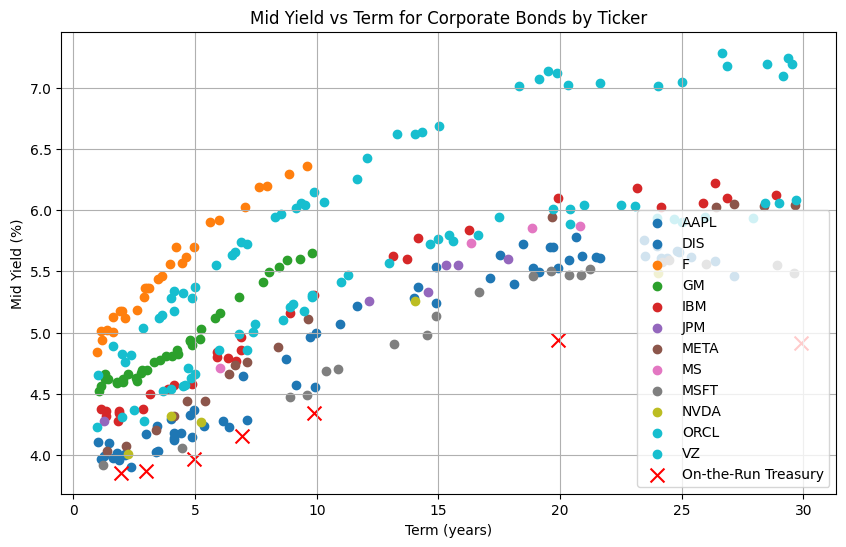

In [38]:
plt.figure(figsize=(10, 6))
colors = plt.cm.get_cmap('tab10', len(unique_ticker))
for ticker in unique_ticker:
    ticker_data = corporate_bond_merged[corporate_bond_merged['ticker_x'] == ticker]
    plt.scatter(ticker_data['TTM'], ticker_data['midYield'], label=ticker, color=colors(unique_ticker.tolist().index(ticker)))


plt.scatter(on_the_run_treasury['TTM'], on_the_run_treasury['midYield'], color='red', label='On-the-Run Treasury', marker='x', s=100)
plt.xlabel('Term (years)')
plt.ylabel('Mid Yield (%)')
plt.title('Mid Yield vs Term for Corporate Bonds by Ticker')
plt.legend()
plt.grid(True)
plt.show()

### - Based on the plot above, it is clear that the credit issuer yields are generally higher than the on-the-run treasury yields. On average, it seems that the credit yield is around 50-100 bips higher. 

------------------------------------------------------------------------------------------
# Problem 4: Underying treasury benchmarks and credit spreads

## a. Add underlying benchmark bond mid yields

Start with the corporate bond symbology dataframe and filter following tickers only: AAPL, IBM, MSFT, ORCL and VZ. Use the column 'und_bench_yield' to identify the underlying benchmark bond for each bond issue.

Add two new columns to the joint corporate bond dataframe:

| und_bench_yield | credit_spread |
|----------|-------|

where 

*  `und_bench_yield` = underlying benchmark bond mid yield and
*  `credit_spread` = (issue yield - underlying benchmark bond mid yield) * 100.

In [79]:
govt_bonds_df = pd.read_excel('data/govt_on_the_run.xlsx')
bench_mark_bond = bond_symbology_df[(bond_symbology_df['ticker'] == 'AAPL') | (bond_symbology_df['ticker'] == 'IBM') | (bond_symbology_df['ticker'] == 'MSFT') | (bond_symbology_df['ticker'] == 'VZ')].copy()
merged_benchmark = bench_mark_bond.merge(govt_bonds_df, left_on='und_bench_isin', right_on='isin', how = 'inner', suffixes = ('_corp', '_bench'))
merged_benchmark.head()
# merged_benchmark = merged_benchmark.merge(bond_market_prices_df, on=['figi_x', 'isin'], how = 'inner')


,ticker_corp,class,figi_corp,isin_corp,und_bench_isin,security,name,type,coupon,cpn_type,dcc,cpn_freq,days_settle,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status,ticker_bench,date,figi_bench,isin_bench
0,AAPL,Corp,BBG004HST0K7,US037833AL42,US912810UT33,AAPL 3.85 05/04/43,APPLE INC,GLOBAL,3.850,FIXED,30/360,2.0,1,2013-05-03,2013-11-04,2013-05-03,2043-05-04,AT MATURITY,Sr Unsecured,3000.0,US,USD,ACTV,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33
1,AAPL,Corp,BBG006F8VWJ7,US037833AT77,US912810UT33,AAPL 4.45 05/06/44,APPLE INC,GLOBAL,4.450,FIXED,30/360,2.0,1,2014-05-06,2014-11-06,2014-05-06,2044-05-06,AT MATURITY,Sr Unsecured,1000.0,US,USD,ACTV,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33
2,AAPL,Corp,BBG0081TNL50,US037833BA77,US912810UT33,AAPL 3.45 02/09/45,APPLE INC,GLOBAL,3.450,FIXED,30/360,2.0,1,2015-02-09,2015-08-09,2015-02-09,2045-02-09,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33
3,AAPL,Corp,BBG008N1BQC1,US037833BH21,US912810UT33,AAPL 4 3/8 05/13/45,APPLE INC,GLOBAL,4.375,FIXED,30/360,2.0,1,2015-05-13,2015-11-13,2015-05-13,2045-05-13,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33
4,AAPL,Corp,BBG00C7QBCQ1,US037833BW97,US91282CPZ85,AAPL 4 1/2 02/23/36,APPLE INC,GLOBAL,4.500,FIXED,30/360,2.0,1,2016-02-23,2016-08-23,2016-02-23,2036-02-23,CALLABLE,Sr Unsecured,1250.0,US,USD,ACTV,GT10 Govt,2026-03-23,BBG01ZZ4GDR9,US91282CPZ85


In [80]:
pd.set_option('display.max_columns', None)
merged_benchmark = merged_benchmark.merge(bond_market_prices_df, left_on='figi_corp', right_on='figi', how = 'inner')
merged_benchmark = merged_benchmark.merge(bond_market_prices_df, left_on='figi_bench', right_on='figi', how = 'inner')
merged_benchmark.head()

,ticker_corp,class_x,figi_corp,isin_corp,und_bench_isin,security,name,type,coupon,cpn_type,dcc,cpn_freq,days_settle,start_date,cpn_first,acc_first,maturity,mty_typ,rank,amt_out,country,currency,status,ticker_bench,date_x,figi_bench,isin_bench,date_y,class_y,ticker_x,isin_x,figi_x,bidPrice_x,askPrice_x,bidYield_x,askYield_x,date,class,ticker_y,isin_y,figi_y,bidPrice_y,askPrice_y,bidYield_y,askYield_y
0,AAPL,Corp,BBG004HST0K7,US037833AL42,US912810UT33,AAPL 3.85 05/04/43,APPLE INC,GLOBAL,3.850,FIXED,30/360,2.0,1,2013-05-03,2013-11-04,2013-05-03,2043-05-04,AT MATURITY,Sr Unsecured,3000.0,US,USD,ACTV,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33,2026-03-23,Corp,AAPL,US037833AL42,BBG004HST0K7,82.414444,82.414444,5.442,5.442,2026-03-23,Govt,T,US912810UT33,BBG02037XBW2,96.0781,96.1093,4.941,4.936
1,AAPL,Corp,BBG006F8VWJ7,US037833AT77,US912810UT33,AAPL 4.45 05/06/44,APPLE INC,GLOBAL,4.450,FIXED,30/360,2.0,1,2014-05-06,2014-11-06,2014-05-06,2044-05-06,AT MATURITY,Sr Unsecured,1000.0,US,USD,ACTV,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33,2026-03-23,Corp,AAPL,US037833AT77,BBG006F8VWJ7,89.116091,89.116091,5.399,5.399,2026-03-23,Govt,T,US912810UT33,BBG02037XBW2,96.0781,96.1093,4.941,4.936
2,AAPL,Corp,BBG0081TNL50,US037833BA77,US912810UT33,AAPL 3.45 02/09/45,APPLE INC,GLOBAL,3.450,FIXED,30/360,2.0,1,2015-02-09,2015-08-09,2015-02-09,2045-02-09,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33,2026-03-23,Corp,AAPL,US037833BA77,BBG0081TNL50,75.855577,75.855577,5.526,5.526,2026-03-23,Govt,T,US912810UT33,BBG02037XBW2,96.0781,96.1093,4.941,4.936
3,AAPL,Corp,BBG008N1BQC1,US037833BH21,US912810UT33,AAPL 4 3/8 05/13/45,APPLE INC,GLOBAL,4.375,FIXED,30/360,2.0,1,2015-05-13,2015-11-13,2015-05-13,2045-05-13,AT MATURITY,Sr Unsecured,2000.0,US,USD,ACTV,GT20 Govt,2026-03-23,BBG02037XBW2,US912810UT33,2026-03-23,Corp,AAPL,US037833BH21,BBG008N1BQC1,86.818216,86.818216,5.497,5.497,2026-03-23,Govt,T,US912810UT33,BBG02037XBW2,96.0781,96.1093,4.941,4.936
4,AAPL,Corp,BBG00C7QBCQ1,US037833BW97,US91282CPZ85,AAPL 4 1/2 02/23/36,APPLE INC,GLOBAL,4.500,FIXED,30/360,2.0,1,2016-02-23,2016-08-23,2016-02-23,2036-02-23,CALLABLE,Sr Unsecured,1250.0,US,USD,ACTV,GT10 Govt,2026-03-23,BBG01ZZ4GDR9,US91282CPZ85,2026-03-23,Corp,AAPL,US037833BW97,BBG00C7QBCQ1,99.575093,99.575093,4.553,4.553,2026-03-23,Govt,T,US91282CPZ85,BBG01ZZ4GDR9,98.3125,98.3437,4.348,4.342


In [81]:
merged_benchmark['und_bench_yield'] = (merged_benchmark['bidYield_y'] + merged_benchmark['askYield_y']) / 2
merged_benchmark['credit_spread'] = (merged_benchmark['bidYield_x'] - merged_benchmark['und_bench_yield']) * 100
result_df = merged_benchmark[['und_bench_yield', 'credit_spread']]
result_df.head()

,und_bench_yield,credit_spread
0,4.9385,50.35
1,4.9385,46.05
2,4.9385,58.75
3,4.9385,55.85
4,4.3450,20.80


## b. Credit spread curve plots

Plot a graph/scatter plot of credit spread curves by TTM (one line per issuer).


## c. Add g-spreads

Add two new columns to the joint corporate bond dataframe:

| interp_tsy_yield | g_spread |
|----------|-------|

where 

*  `interp_tsy_yield` = interpolated treasury yield (using on-the-run treasuries only), matching the issue maturity
*  `credit_spread` = (issue yield - underlying benchmark bond mid yield) * 100.

## d. G-spread curve plots

Plot a graph/scatter plot of g-spread curves by TTM (one line per issuer).
